<a href="https://colab.research.google.com/github/Nawaf-Alorabi/Classification_Mini_Project/blob/main/test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import kagglehub
from kagglehub import KaggleDatasetAdapter

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "anishdevedward/loan-approval-dataset",
    "loan_approval.csv"
)

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

PALETTE = {True: "#2ecc71", False: "#e74c3c"}
print("Libraries loaded ✅")

/tmp/ipykernel_5119/113055002.py:9: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 113k/113k [00:00<00:00, 62.5MB/s]

Libraries loaded ✅


In [2]:
df.head()

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50.0,False
1,Brandon Hall,New Jamesside,44592,729,15446,28,55.0,False
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45.0,False
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50.0,False
4,Valerie Gray,Mariastad,66048,496,47174,4,25.0,False


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            2000 non-null   object 
 1   city            2000 non-null   object 
 2   income          2000 non-null   int64  
 3   credit_score    2000 non-null   int64  
 4   loan_amount     2000 non-null   int64  
 5   years_employed  2000 non-null   int64  
 6   points          2000 non-null   float64
 7   loan_approved   2000 non-null   bool   
dtypes: bool(1), float64(1), int64(4), object(2)
memory usage: 111.5+ KB


In [4]:
df.shape

(2000, 8)

In [5]:
df.describe()

,income,credit_score,loan_amount,years_employed,points
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,90585.977000,573.946000,25308.503000,20.441000,56.680000
std,34487.874907,160.564945,14207.320147,11.777813,18.638033
min,30053.000000,300.000000,1022.000000,0.000000,10.000000
25%,61296.250000,433.000000,12748.750000,10.000000,45.000000
50%,90387.500000,576.000000,25661.500000,21.000000,55.000000
75%,120099.750000,715.000000,37380.500000,31.000000,70.000000
max,149964.000000,850.000000,49999.000000,40.000000,100.000000


In [6]:
df.isnull().sum()

,0
name,0
city,0
income,0
credit_score,0
loan_amount,0
years_employed,0
points,0
loan_approved,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df = df.drop(["name", "city"], axis=1)

In [9]:
df["loan_approved"] = df["loan_approved"].astype(int)

In [10]:
df["loan_approved"].value_counts()

,count
loan_approved,
0,1121
1,879


# Key visualization

### Target Variable Distribution - bar + pie

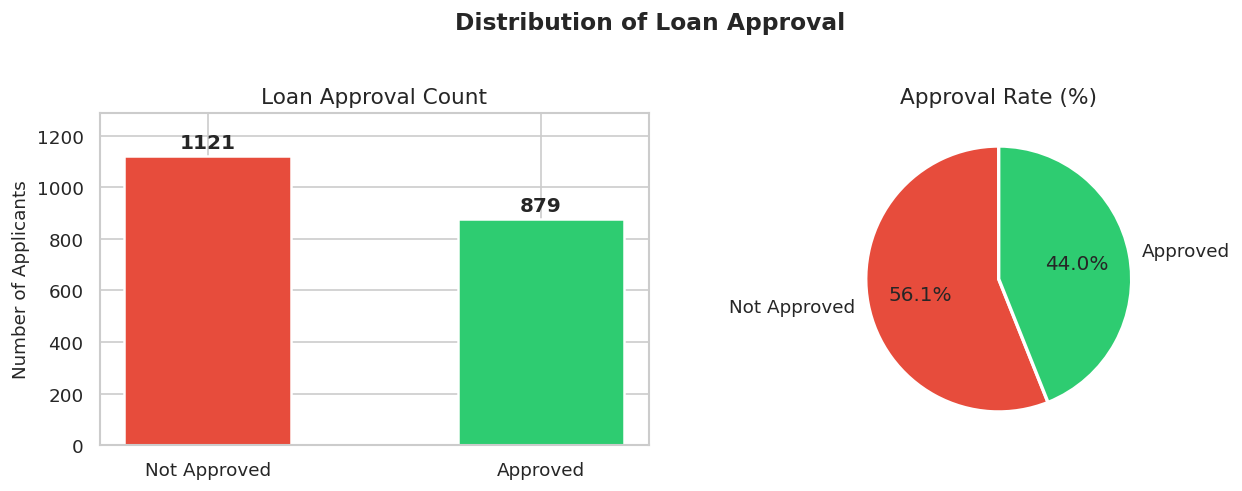

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

counts = df["loan_approved"].value_counts()
bars = axes[0].bar(
    ["Not Approved", "Approved"],
    [counts[0], counts[1]],
    color=[PALETTE[False], PALETTE[True]],
    edgecolor="white", linewidth=1.5, width=0.5
)
for bar, val in zip(bars, [counts[0], counts[1]]):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 15,
                 f"{val}", ha="center", va="bottom", fontweight="bold", fontsize=12)
axes[0].set_title("Loan Approval Count")
axes[0].set_ylabel("Number of Applicants")
axes[0].set_ylim(0, max(counts) * 1.15)

axes[1].pie(
    [counts[0], counts[1]],
    labels=["Not Approved", "Approved"],
    colors=[PALETTE[False], PALETTE[True]],
    autopct="%1.1f%%", startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
axes[1].set_title("Approval Rate (%)")

plt.suptitle("Distribution of Loan Approval", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

> Insight: 879 loans approved (44.0%) vs 1121 rejected (56.0%).

### Histograms of All Numeric Features - histogram

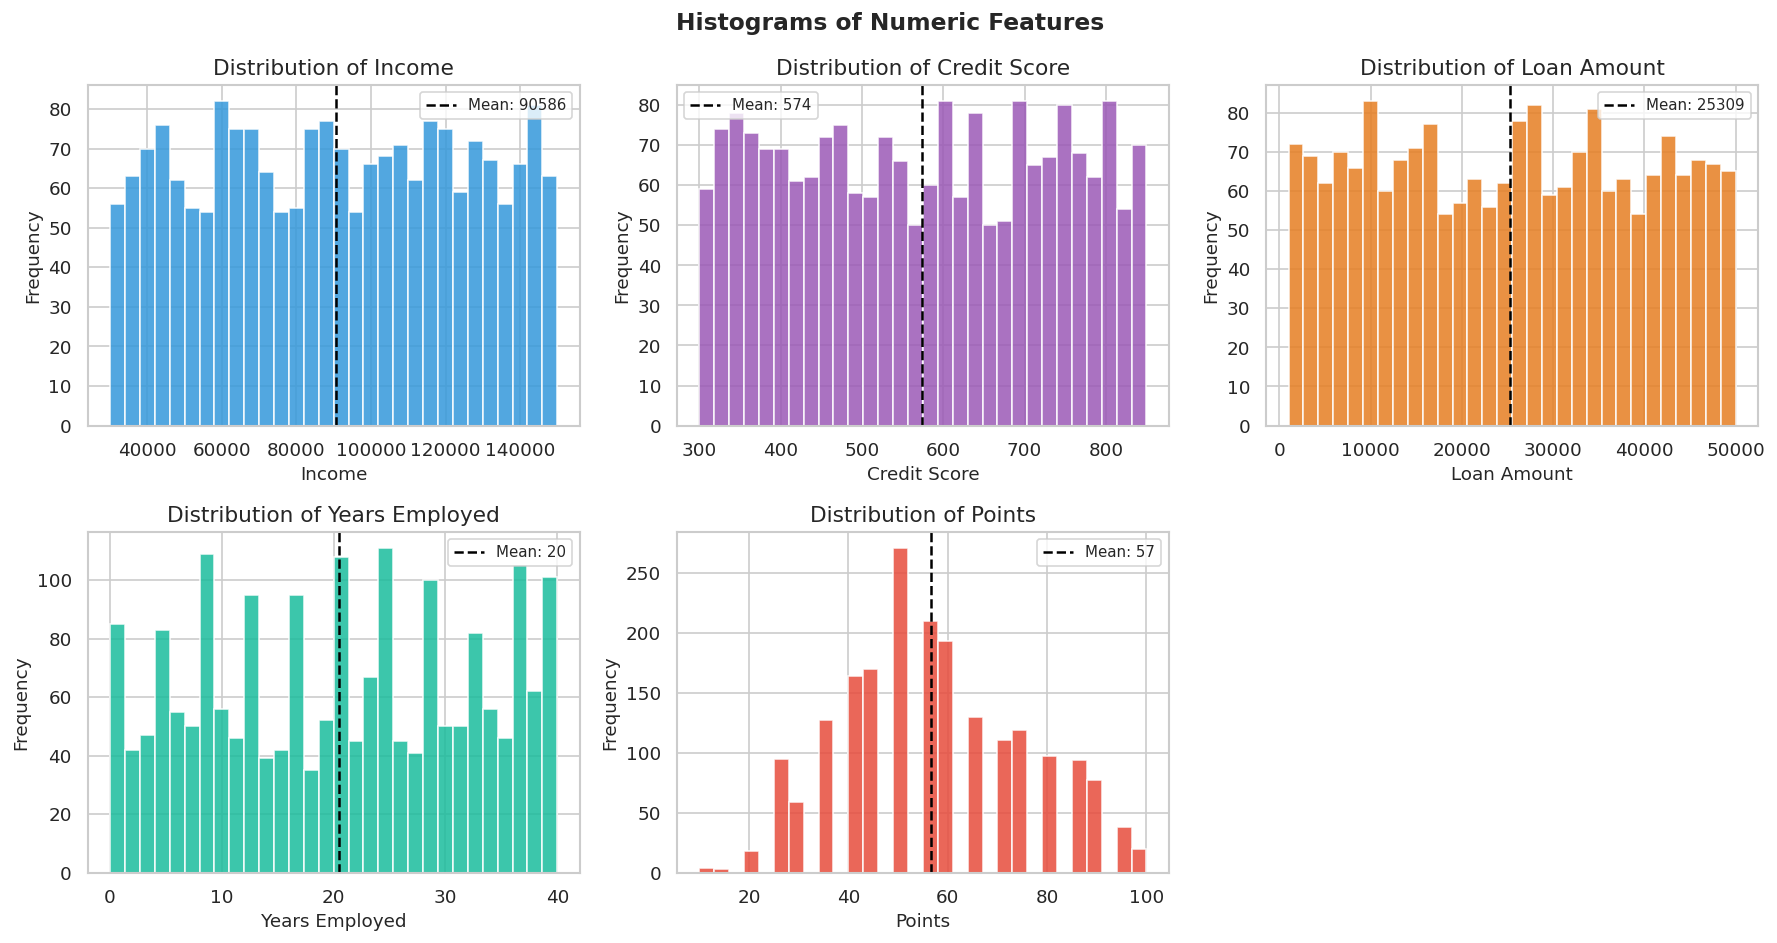

In [12]:
num_cols = ["income", "credit_score", "loan_amount", "years_employed", "points"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
colors = ["#3498db", "#9b59b6", "#e67e22", "#1abc9c", "#e74c3c"]

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color=colors[i], edgecolor="white", alpha=0.85)
    axes[i].axvline(df[col].mean(), color="black", linestyle="--", linewidth=1.5,
                    label=f"Mean: {df[col].mean():.0f}")
    axes[i].set_title(f"Distribution of {col.replace('_', ' ').title()}")
    axes[i].set_xlabel(col.replace("_", " ").title())
    axes[i].set_ylabel("Frequency")
    axes[i].legend(fontsize=9)

axes[5].set_visible(False)
plt.suptitle("Histograms of Numeric Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

> Insight: Income and loan amount are roughly uniform. Credit score spreads between 300–850. Points has discrete values.

### Feature Distributions Split by Approval Status

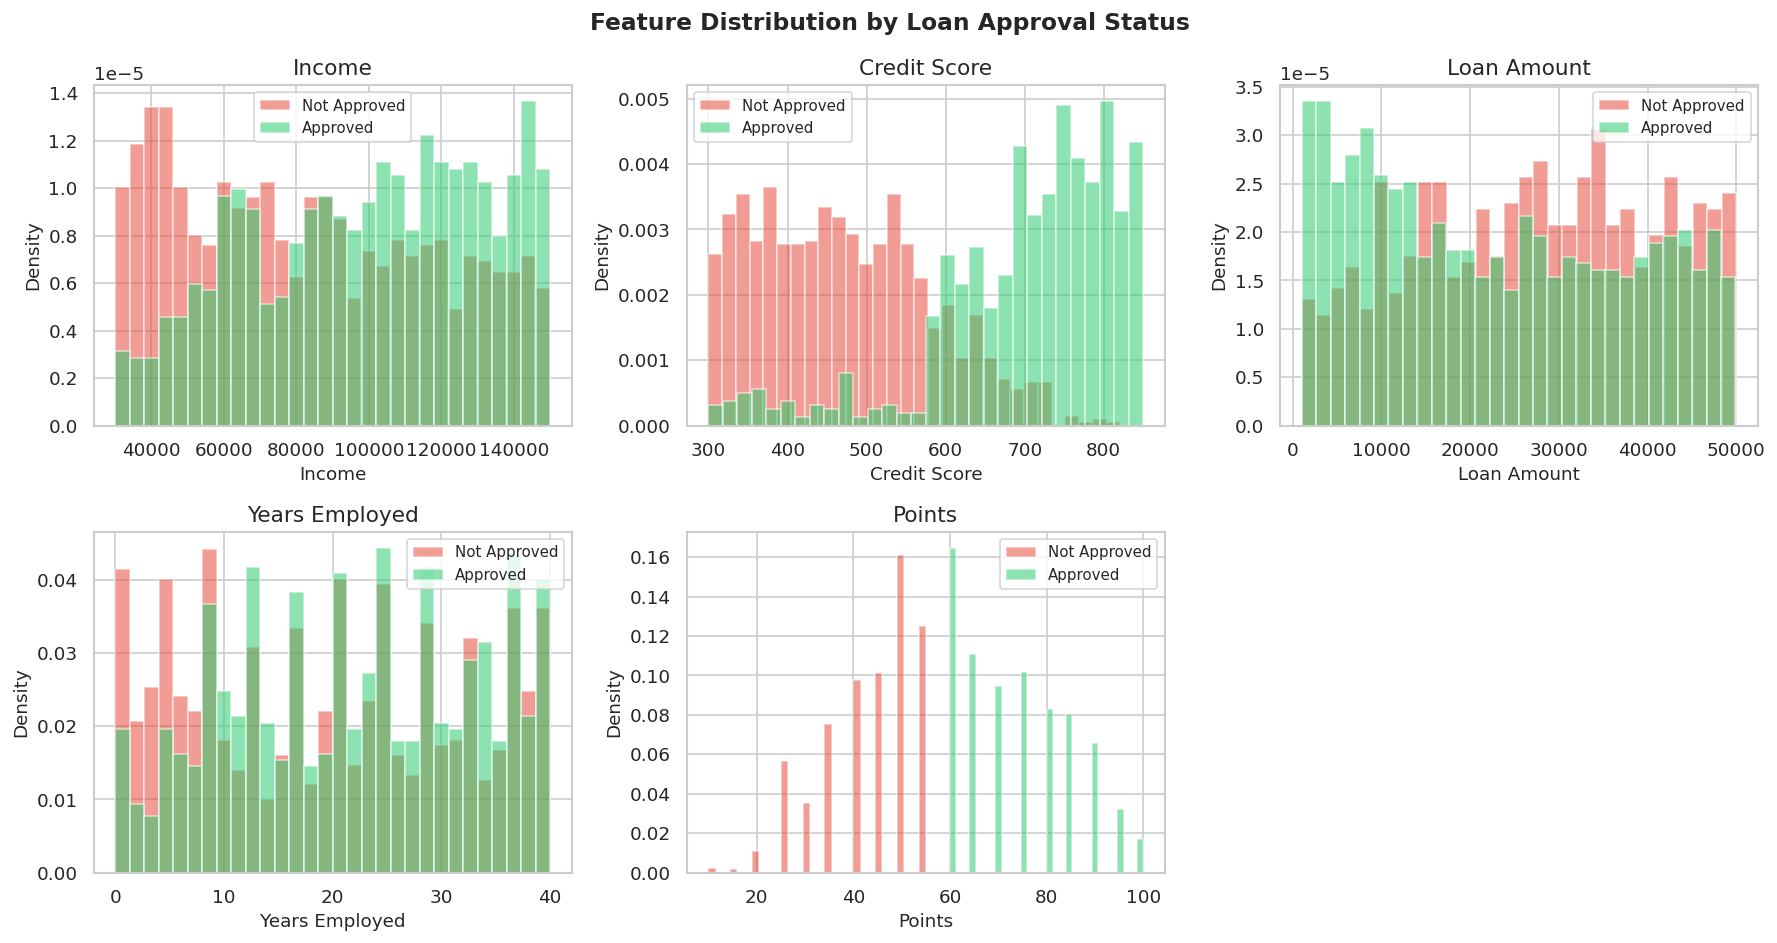

In [13]:
approved     = df[df["loan_approved"] == True]
not_approved = df[df["loan_approved"] == False]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(not_approved[col], bins=30, color=PALETTE[False], alpha=0.55,
                 edgecolor="white", label="Not Approved", density=True)
    axes[i].hist(approved[col],     bins=30, color=PALETTE[True],  alpha=0.55,
                 edgecolor="white", label="Approved",     density=True)
    axes[i].set_title(col.replace("_", " ").title())
    axes[i].set_xlabel(col.replace("_", " ").title())
    axes[i].set_ylabel("Density")
    axes[i].legend(fontsize=9)

axes[5].set_visible(False)
plt.suptitle("Feature Distribution by Loan Approval Status", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

> Insight: Approved loans tend to have higher credit scores and points. These are likely the strongest predictors for the Random Forest model.

###  Feature Spread by Loan Approval Status - BoxPlots

/tmp/ipykernel_5119/188705692.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(
/tmp/ipykernel_5119/188705692.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(
/tmp/ipykernel_5119/188705692.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(
/tmp/ipykernel_5119/188705692.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(
/tmp/ipykernel_5119/188705692.py:6: MatplotlibDeprecationWarning: The 'labels' param

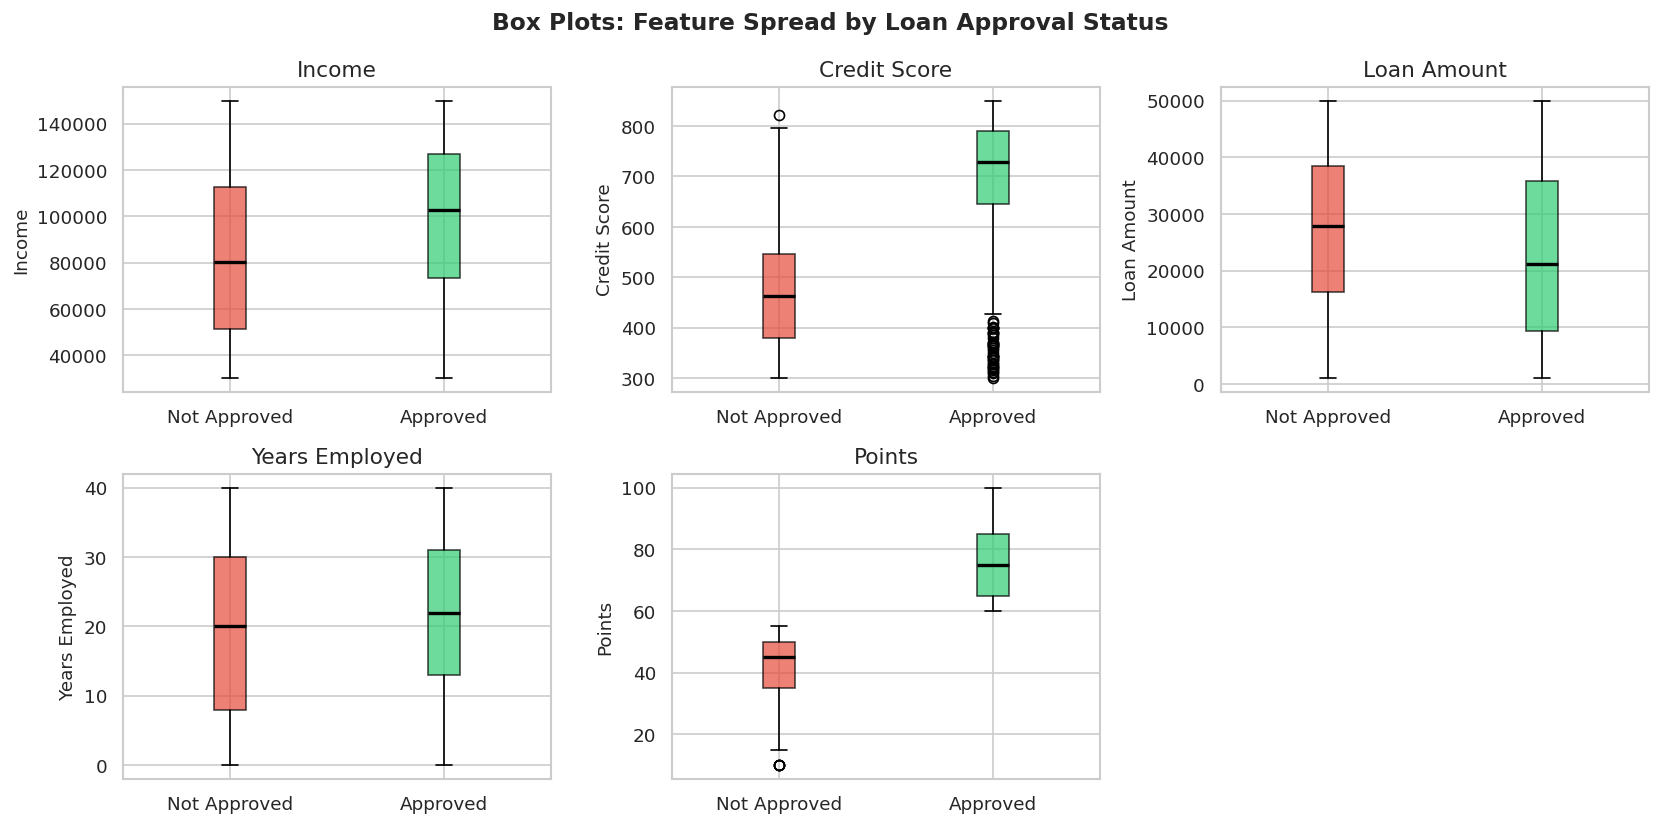

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data_groups = [not_approved[col].values, approved[col].values]
    bp = axes[i].boxplot(
        data_groups, patch_artist=True,
        labels=["Not Approved", "Approved"],
        medianprops={"color": "black", "linewidth": 2}
    )
    for patch, color in zip(bp["boxes"], [PALETTE[False], PALETTE[True]]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[i].set_title(col.replace("_", " ").title())
    axes[i].set_ylabel(col.replace("_", " ").title())

axes[5].set_visible(False)
plt.suptitle("Box Plots: Feature Spread by Loan Approval Status", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

> Insight: Median credit_score and points are noticeably higher for approved loans.

### Correlation Heatmap

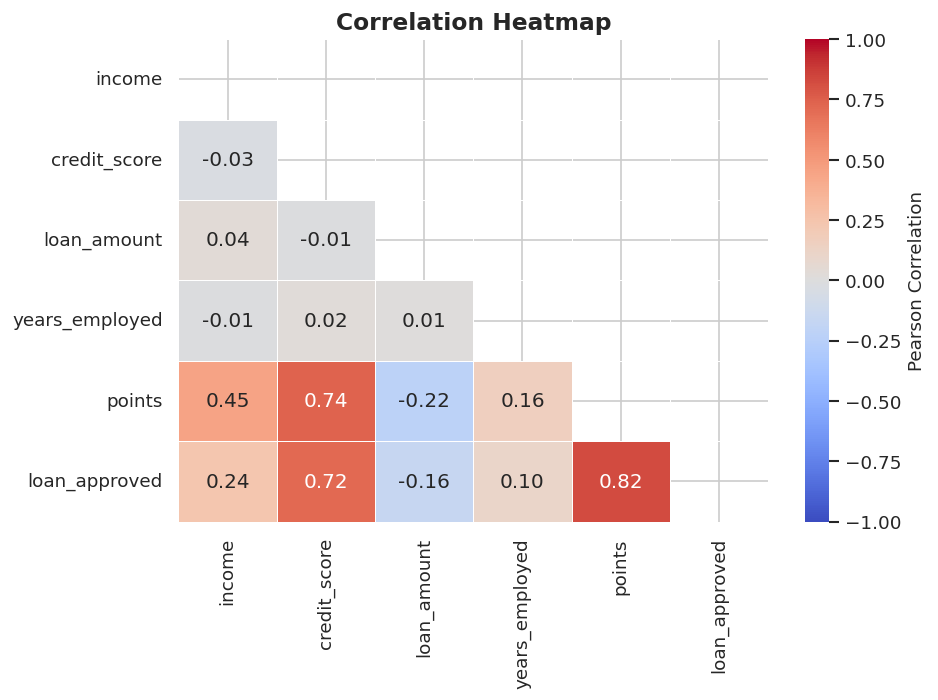

In [15]:
df_corr = df[num_cols].copy()
df_corr["loan_approved"] = df["loan_approved"].astype(int)

corr_matrix = df_corr.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", vmin=-1, vmax=1,
    linewidths=0.5, ax=ax,
    cbar_kws={"label": "Pearson Correlation"}
)
ax.set_title("Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

> 📌 Feature correlations with loan_approved:
- points            0.821415
- credit_score      0.715788
- income            0.238066
- years_employed    0.104408
- loan_amount      -0.157859



### Scatter Plots

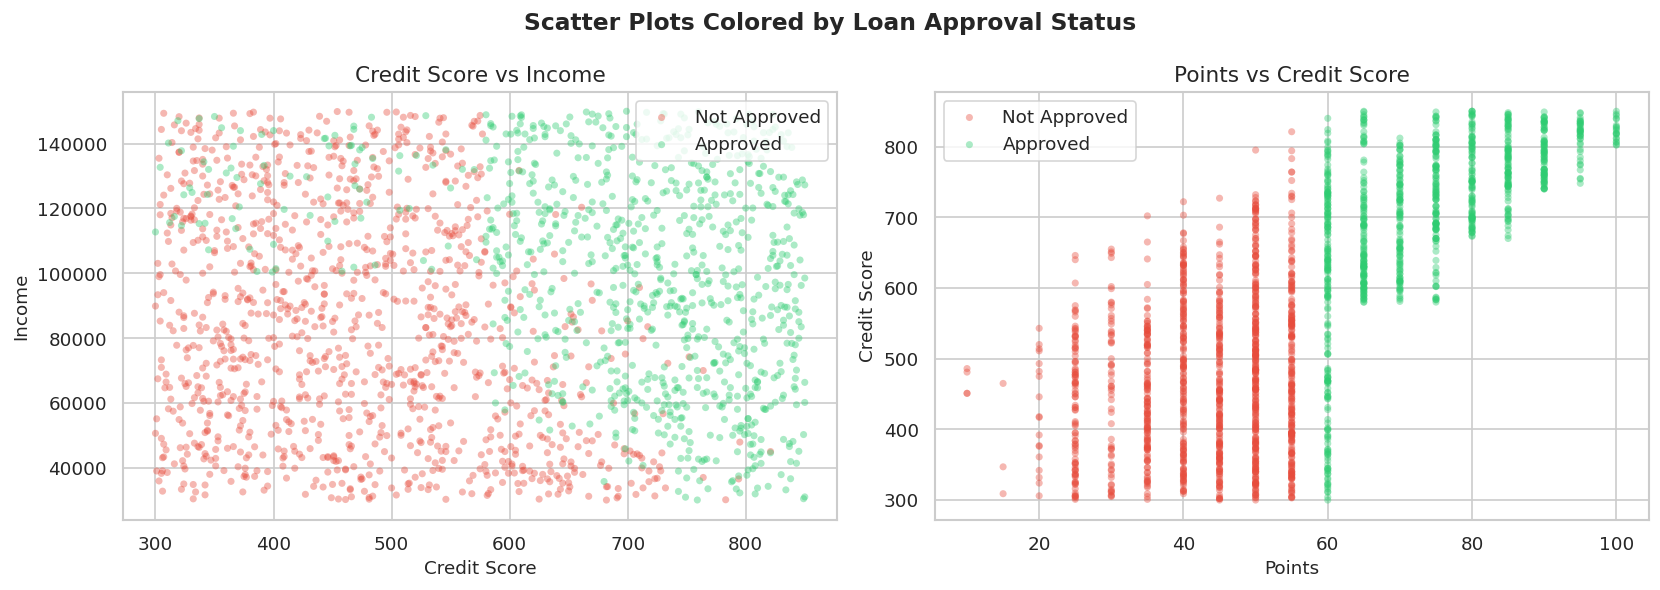

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for status, group in df.groupby("loan_approved"):
    label = "Approved" if status else "Not Approved"
    axes[0].scatter(group["credit_score"], group["income"],
                    c=PALETTE[status], label=label, alpha=0.4, s=18, edgecolors="none")
axes[0].set_xlabel("Credit Score")
axes[0].set_ylabel("Income")
axes[0].set_title("Credit Score vs Income")
axes[0].legend()

for status, group in df.groupby("loan_approved"):
    label = "Approved" if status else "Not Approved"
    axes[1].scatter(group["points"], group["credit_score"],
                    c=PALETTE[status], label=label, alpha=0.4, s=18, edgecolors="none")
axes[1].set_xlabel("Points")
axes[1].set_ylabel("Credit Score")
axes[1].set_title("Points vs Credit Score")
axes[1].legend()

plt.suptitle("Scatter Plots Colored by Loan Approval Status", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


> Insight: Points vs Credit Score shows the clearest separation higher points AND higher credit score = more likely approved.

### Normalized Mean Feature Values

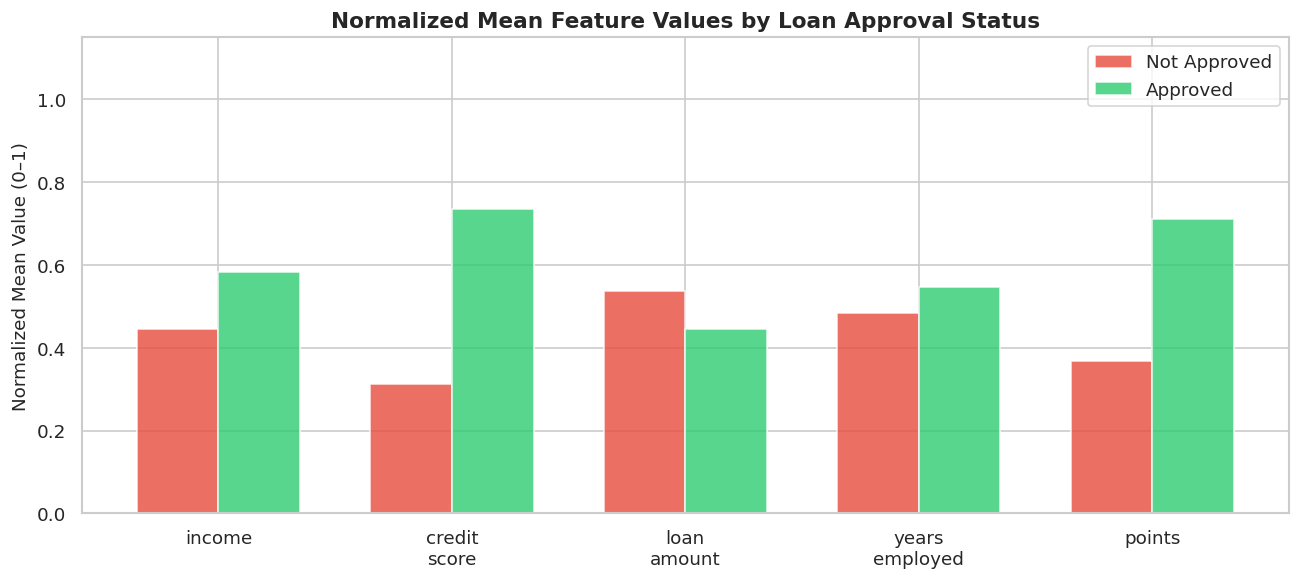

In [17]:
means = df.groupby("loan_approved")[num_cols].mean()
means_norm = (means - df[num_cols].min()) / (df[num_cols].max() - df[num_cols].min())

x = np.arange(len(num_cols))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width/2, means_norm.loc[0], width, label="Not Approved",
       color=PALETTE[False], alpha=0.8, edgecolor="white")
ax.bar(x + width/2, means_norm.loc[1],  width, label="Approved",
       color=PALETTE[True],  alpha=0.8, edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels([c.replace("_", "\n") for c in num_cols])
ax.set_ylabel("Normalized Mean Value (0–1)")
ax.set_title("Normalized Mean Feature Values by Loan Approval Status", fontweight="bold")
ax.legend()
ax.set_ylim(0, 1.15)
plt.tight_layout()
plt.show()

> Insight: credit_score and points have the biggest gap between approved and rejected groups these will likely be the top features in Random Forest.

In [18]:
#Note: Before you begin training the model, ensure the data is balanced to prevent any bias towards the model!

#Pytorch model

In [19]:
import torch
import numpy as np
from sklearn.model_selection import train_test_split

In [20]:
class DecisionTree:
    def __init__(self, max_depth=5, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree = None

    def _gini_impurity(self, y):
        if y.shape[0] == 0: return 0.0
        _, counts = torch.unique(y, return_counts=True)
        probabilities = counts.float() / y.shape[0]
        return 1.0 - torch.sum(probabilities ** 2).item()

    def _best_split(self, X, y):
        best_gini = float('inf')
        best_split = None
        n_samples, n_features = X.shape

        # Random Forest Feature Subsetting
        n_subset = max(1, int(n_features ** 0.5))
        feature_indices = torch.randperm(n_features)[:n_subset].tolist()

        for feature_idx in feature_indices:
            thresholds = torch.unique(X[:, feature_idx])
            for threshold in thresholds:
                left_indices = torch.where(X[:, feature_idx] <= threshold)[0]
                right_indices = torch.where(X[:, feature_idx] > threshold)[0]

                if len(left_indices) == 0 or len(right_indices) == 0:
                    continue

                gini_left = self._gini_impurity(y[left_indices])
                gini_right = self._gini_impurity(y[right_indices])

                n_left, n_right = len(left_indices), len(right_indices)
                weighted_gini = (n_left / n_samples) * gini_left + (n_right / n_samples) * gini_right

                if weighted_gini < best_gini:
                    best_gini = weighted_gini
                    best_split = (feature_idx, threshold.item(), left_indices, right_indices)

        return best_split

    def fit(self, X, y, depth=0):
        if depth >= self.max_depth or X.shape[0] < self.min_samples_split:
            self.tree = torch.mode(y).values.item()
            return

        best_split = self._best_split(X, y)
        if best_split is None:
            self.tree = torch.mode(y).values.item()
            return

        feature, threshold, left_indices, right_indices = best_split

        left_child = DecisionTree(self.max_depth, self.min_samples_split)
        right_child = DecisionTree(self.max_depth, self.min_samples_split)

        left_child.fit(X[left_indices], y[left_indices], depth + 1)
        right_child.fit(X[right_indices], y[right_indices], depth + 1)

        self.tree = {
            'feature': feature,
            'threshold': threshold,
            'left': left_child,
            'right': right_child
        }

    def predict(self, X):
        # This predict method belongs to the DecisionTree!
        predictions = torch.zeros(X.shape[0], dtype=torch.int64)
        for i in range(X.shape[0]):
            predictions[i] = self._predict_single(X[i], self.tree)
        return predictions

    def _predict_single(self, x, node):
        if not isinstance(node, dict):
            return node
        if x[node['feature']] <= node['threshold']:
            return self._predict_single(x, node['left'].tree)
        else:
            return self._predict_single(x, node['right'].tree)

In [21]:
class RandomForest:
    def __init__(self, n_estimators=10, max_depth=5, min_samples_split=2):
        self.n_estimators = n_estimators
        self.trees = [DecisionTree(max_depth=max_depth, min_samples_split=min_samples_split) for _ in range(n_estimators)]

    def fit(self, X, y):
        for tree in self.trees:
            # Bootstrap sample
            indices = torch.randint(0, X.shape[0], (X.shape[0],))
            X_sample, y_sample = X[indices], y[indices]
            tree.fit(X_sample, y_sample)

    def predict(self, X):
        # This predict method belongs to the RandomForest!
        # It collects predictions from each individual DecisionTree and takes a majority vote.
        tree_preds = torch.stack([tree.predict(X) for tree in self.trees], dim=1)
        return torch.mode(tree_preds, dim=1).values

In [22]:
X = df.drop("loan_approved",axis = 1)
y= df["loan_approved"]

In [23]:
X_tensors = torch.tensor(X.values,dtype=torch.float32)
y_tensors = torch.tensor(y.values,dtype=torch.int64)

In [24]:
X_train,X_test,y_train,y_test = train_test_split(
    X_tensors.numpy(), y_tensors.numpy(), test_size=0.2, random_state=42
)
X_train = torch.tensor(X_train)
X_test = torch.tensor(X_test)
y_train = torch.tensor(y_train)
y_test = torch.tensor(y_test)

In [25]:
print("Training Custom Random Forest...")
rf = RandomForest(n_estimators=5, max_depth=5, min_samples_split=2)
rf.fit(X_train, y_train)
print("Training Complete!")
predictions = rf.predict(X_test)

Training Custom Random Forest...
Training Complete!


In [26]:
from sklearn.metrics import f1_score, recall_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [27]:
y_true = y_test.numpy()
y_pred = predictions.numpy()


In [28]:
f1 = f1_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)

print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print("-" * 30)

Recall: 1.0000
F1 Score: 1.0000
------------------------------


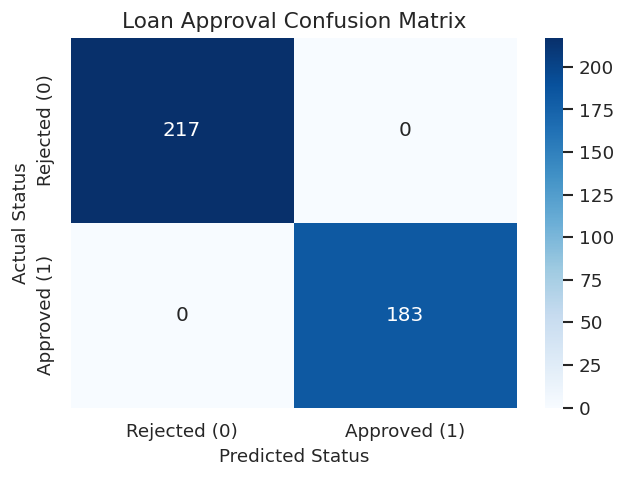

In [29]:
cm = confusion_matrix(y_true, y_pred)

# 4. Plot the Confusion Matrix beautifully
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected (0)', 'Approved (1)'],
            yticklabels=['Rejected (0)', 'Approved (1)'])

plt.ylabel('Actual Status')
plt.xlabel('Predicted Status')
plt.title('Loan Approval Confusion Matrix')
plt.show()